In [1]:
import pandas as pd
df=pd.read_csv('/content/Mall_Customers.csv')
print(df)

     CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]


In [2]:
# Remove CustomerID column
print("---- Removing CustomerID column ----")
df=df.drop('CustomerID',axis=1)
print(df)
print("\n")
print("CustomerID column has removed successfully.")

---- Removing CustomerID column ----
      Genre  Age  Annual Income (k$)  Spending Score (1-100)
0      Male   19                  15                      39
1      Male   21                  15                      81
2    Female   20                  16                       6
3    Female   23                  16                      77
4    Female   31                  17                      40
..      ...  ...                 ...                     ...
195  Female   35                 120                      79
196  Female   45                 126                      28
197    Male   32                 126                      74
198    Male   32                 137                      18
199    Male   30                 137                      83

[200 rows x 4 columns]


CustomerID column has removed successfully.


In [3]:
# Converting categorical column to numbers
print("---- Converting categorical column to numbers ----")
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Genre']=le.fit_transform(df['Genre'])
print(df)
print("\n")
print("Categorical column has converted to numbers successfully.")

---- Converting categorical column to numbers ----
     Genre  Age  Annual Income (k$)  Spending Score (1-100)
0        1   19                  15                      39
1        1   21                  15                      81
2        0   20                  16                       6
3        0   23                  16                      77
4        0   31                  17                      40
..     ...  ...                 ...                     ...
195      0   35                 120                      79
196      0   45                 126                      28
197      1   32                 126                      74
198      1   32                 137                      18
199      1   30                 137                      83

[200 rows x 4 columns]


Categorical column has converted to numbers successfully.


In [5]:
# Scale the data
print("---- Scaling the data ----")
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df=sc.fit_transform(df)
print(df)
print("\n")
print("Data has scaled successfully.")

---- Scaling the data ----
[[ 1.12815215 -1.42456879 -1.73899919 -0.43480148]
 [ 1.12815215 -1.28103541 -1.73899919  1.19570407]
 [-0.88640526 -1.3528021  -1.70082976 -1.71591298]
 [-0.88640526 -1.13750203 -1.70082976  1.04041783]
 [-0.88640526 -0.56336851 -1.66266033 -0.39597992]
 [-0.88640526 -1.20926872 -1.66266033  1.00159627]
 [-0.88640526 -0.27630176 -1.62449091 -1.71591298]
 [-0.88640526 -1.13750203 -1.62449091  1.70038436]
 [ 1.12815215  1.80493225 -1.58632148 -1.83237767]
 [-0.88640526 -0.6351352  -1.58632148  0.84631002]
 [ 1.12815215  2.02023231 -1.58632148 -1.4053405 ]
 [-0.88640526 -0.27630176 -1.58632148  1.89449216]
 [-0.88640526  1.37433211 -1.54815205 -1.36651894]
 [-0.88640526 -1.06573534 -1.54815205  1.04041783]
 [ 1.12815215 -0.13276838 -1.54815205 -1.44416206]
 [ 1.12815215 -1.20926872 -1.54815205  1.11806095]
 [-0.88640526 -0.27630176 -1.50998262 -0.59008772]
 [ 1.12815215 -1.3528021  -1.50998262  0.61338066]
 [ 1.12815215  0.94373197 -1.43364376 -0.82301709]
 [-0

WCSS Values calculated successfully:
[800.0000000000005, 597.9472937932285, 494.8037500130456, 395.3920903479796, 351.7432061711911, 277.3897401985192, 251.1548491119017, 211.98576294959312, 185.72807688711427, 152.02983429775696]


---- Plotting Elbow Method ----


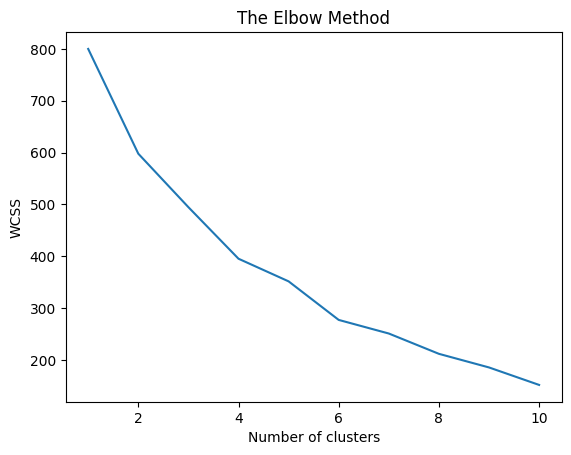



Elbow Method has plotted successfully.


In [18]:
# 1. Use Elbow Method for Optimal K
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
  kmeans.fit(df)
  wcss.append(kmeans.inertia_)
print("WCSS Values calculated successfully:")
print(wcss)
print("\n")
print("---- Plotting Elbow Method ----")
import matplotlib.pyplot as plt
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()
print("\n")
print("Elbow Method has plotted successfully.")

In [19]:
# 2. Perform cluster assignment
kmeans=KMeans(n_clusters=4,init='k-means++',random_state=42, n_init=10)
y_kmeans=kmeans.fit_predict(df)
print("Cluster assignment has performed successfully.")
print("First 10 cluster tags:", y_kmeans[:10])

Cluster assignment has performed successfully.
First 10 cluster tags: [1 1 0 2 0 2 0 2 3 2]


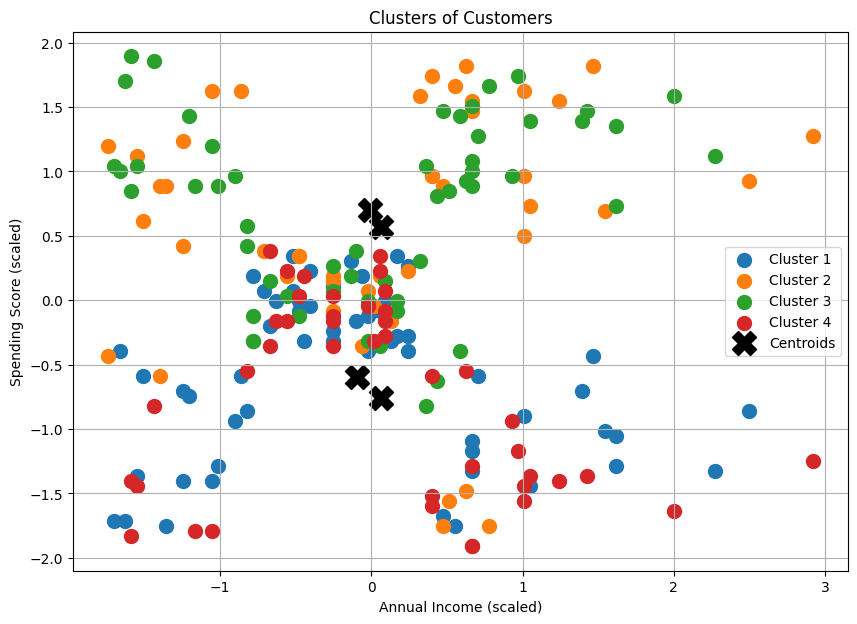

In [21]:
# 3. Visualize clusters and centroid
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
# Plot each cluster
for i in range(len(kmeans.cluster_centers_)):
    plt.scatter(df[y_kmeans == i, 2], df[y_kmeans == i, 3], s = 100, label = f'Cluster {i+1}')

# Plot the centroids
plt.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3], s = 300, c = 'black', marker='X', label = 'Centroids')

plt.title('Clusters of Customers')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
import pandas as pd


cluster_centers = kmeans.cluster_centers_
cluster_df = pd.DataFrame(cluster_centers, columns=['Genre_scaled', 'Age_scaled', 'Annual_Income_scaled', 'Spending_Score_scaled'])

print("Cluster Centers (Scaled Features):")
display(cluster_df)

print("\n--- Interpretation Guidelines ---")
print("Genre_scaled: Negative values typically indicate 'Female' (0 before scaling), positive values indicate 'Male' (1 before scaling).")
print("Age_scaled, Annual_Income_scaled, Spending_Score_scaled: Negative values mean below average, positive values mean above average for the respective feature.")

Cluster Centers (Scaled Features):


,Genre_scaled,Age_scaled,Annual_Income_scaled,Spending_Score_scaled
0,-0.886405,0.642568,-0.094987,-0.594940
1,1.128152,-0.778669,0.064091,0.567808
2,-0.886405,-0.750475,-0.005017,0.697956
3,1.128152,0.996703,0.063143,-0.759239



--- Interpretation Guidelines ---
Genre_scaled: Negative values typically indicate 'Female' (0 before scaling), positive values indicate 'Male' (1 before scaling).
Age_scaled, Annual_Income_scaled, Spending_Score_scaled: Negative values mean below average, positive values mean above average for the respective feature.
